In [3]:
import pandas as pd
df_dengue = pd.read_csv('dengue_data.csv')

In [4]:
df_dengue.head()

,fever_temperature,platelet_count,white_blood_cell_count,joint_pain,headache,vomiting,rash,fatigue,dengue
0,38.498160,295310,3659,1,1,1,0,0,0
1,40.802857,100015,5811,0,1,0,0,0,1
2,39.927976,298550,10098,1,1,1,1,1,0
3,39.394634,172096,9546,1,1,1,1,1,0
4,37.624075,157059,4986,0,0,1,0,1,1


In [5]:
df_dengue.isnull().sum()

,0
fever_temperature,0
platelet_count,0
white_blood_cell_count,0
joint_pain,0
headache,0
vomiting,0
rash,0
fatigue,0
dengue,0


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df_dengue.drop('dengue', axis=1)
y = df_dengue['dengue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4

Confusion Matrix:
 [[ 9  5]
 [13  3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.64      0.50        14
           1       0.38      0.19      0.25        16

    accuracy                           0.40        30
   macro avg       0.39      0.42      0.38        30
weighted avg       0.39      0.40      0.37        30



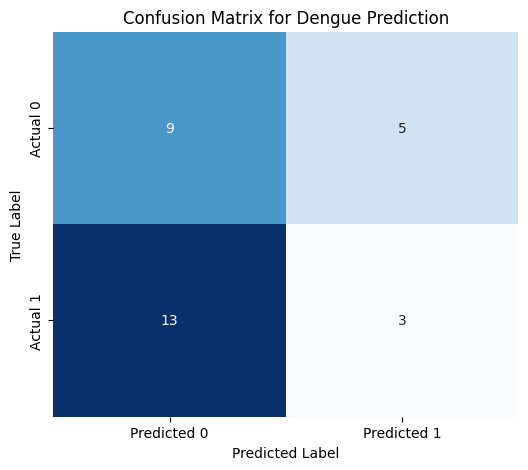

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Dengue Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()